In [1]:
import kagglehub
import shutil
import os

print(" Downloading dataset via Google's servers...")
# Download latest version from Kaggle
cache_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(" Download complete! Located at:", cache_path)

# Ensure the destination data folder exists
target_path = "ml_training/data"
os.makedirs(target_path, exist_ok=True)

# Move the dataset into your project directory
print("Moving dataset to the training folder...")
shutil.copytree(cache_path, target_path, dirs_exist_ok=True)
print(f"Dataset successfully moved to {target_path}!")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
 Download complete! Located at: /kaggle/input/chest-xray-pneumonia
Moving dataset to the training folder...
Dataset successfully moved to ml_training/data!


In [4]:
!python ml_training/src/train.py

 Starting training pipeline on device: CUDA
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 139MB/s]
Epoch 1/5 | Train Loss: 0.3681 | Val Loss: 0.3043 | Val Recall: 0.8718
 New best model saved! (Recall: 0.8718)
Epoch 2/5 | Train Loss: 0.2397 | Val Loss: 0.3086 | Val Recall: 0.8692
Epoch 3/5 | Train Loss: 0.2075 | Val Loss: 0.2706 | Val Recall: 0.9590
 New best model saved! (Recall: 0.9590)
Epoch 4/5 | Train Loss: 0.1962 | Val Loss: 0.2641 | Val Recall: 0.9436
Epoch 5/5 | Train Loss: 0.1734 | Val Loss: 0.2608 | Val Recall: 0.9359

Loading best model for final evaluation...

FINAL EVALUATION METRICS
Confusion Matrix:
[[189  45]
 [ 16 374]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.81      0.86       234
   PNEUMONIA       0.89      0.96      0.92       390

    accuracy                           0.90      

In [7]:
from google.colab import files

print("Downloading the trained model to your local machine...")
files.download('xray_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

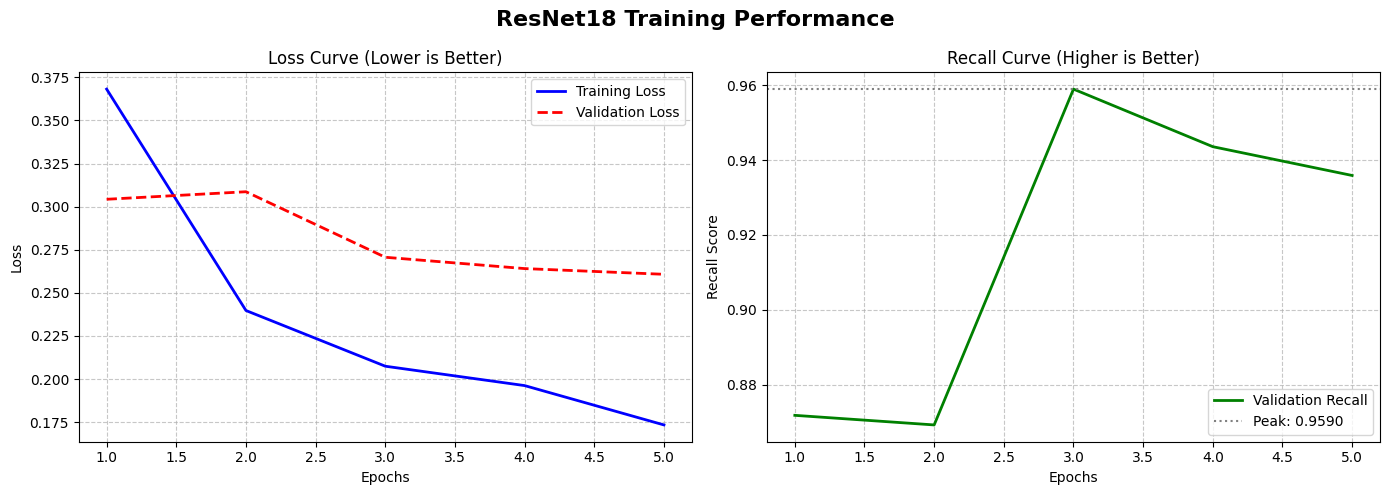

In [5]:
import json
import matplotlib.pyplot as plt

# 1. Load the history you saved during training
with open("training_results.json", "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

# 2. Create a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet18 Training Performance', fontsize=16, fontweight='bold')

# Plot 1: Training vs Validation Loss
ax1.plot(epochs, history["train_loss"], 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, history["val_loss"], 'r--', label='Validation Loss', linewidth=2)
ax1.set_title('Loss Curve (Lower is Better)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Validation Recall
ax2.plot(epochs, history["val_recall"], 'g-', label='Validation Recall', linewidth=2)
ax2.set_title('Recall Curve (Higher is Better)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Recall Score')
ax2.axhline(y=max(history["val_recall"]), color='gray', linestyle=':', label=f'Peak: {max(history["val_recall"]):.4f}')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

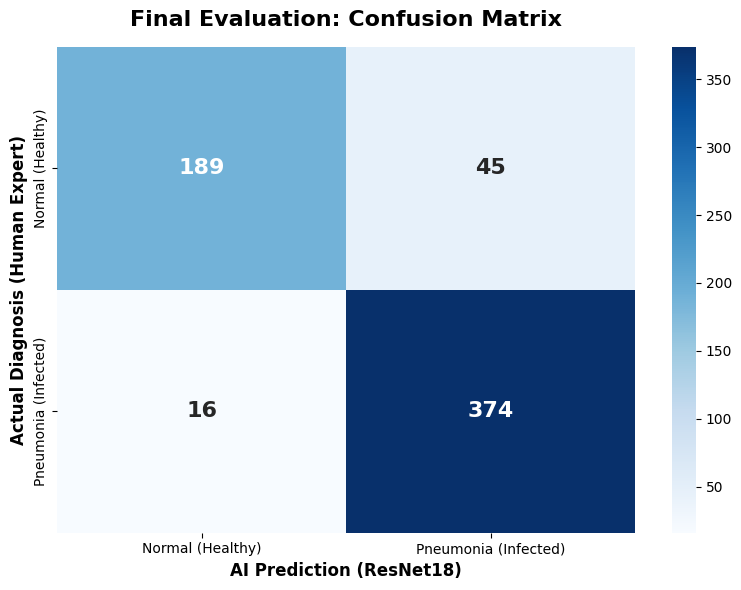

In [6]:
import seaborn as sns
import numpy as np

# Using the exact numbers from your successful evaluation
cm = np.array([[189, 45],
               [16, 374]])

labels = ['Normal (Healthy)', 'Pneumonia (Infected)']

plt.figure(figsize=(8, 6))
# Create the heatmap using a medical blue color palette
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Final Evaluation: Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual Diagnosis (Human Expert)', fontsize=12, fontweight='bold')
plt.xlabel('AI Prediction (ResNet18)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()